<a href="https://colab.research.google.com/github/Jenifar5/Applied-ai/blob/main/Object.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu
Upload one or multiple images:


Saving images.jpg to images (2).jpg

Total images uploaded: 1

========== IMAGE 1 ==========


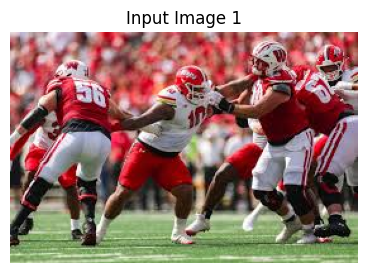

Inference Time: 0.2499 sec | FPS: 4.00
person (0.83) → W:108, H:143, Area:15444
person (0.79) → W:82, H:148, Area:12136
person (0.72) → W:122, H:162, Area:19764
person (0.39) → W:34, H:105, Area:3570
Total Objects Detected: 4


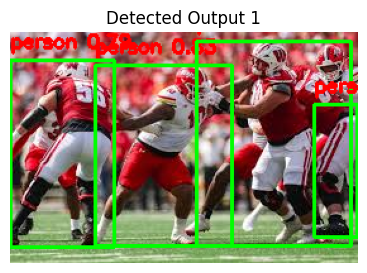


===== PERFORMANCE =====
CPU Latency: 0.1981
GPU Latency: 0.1894
GPU not available


In [23]:
import cv2
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from google.colab import files
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device:", device)
model = YOLO("yolov8n.pt")
model.to(device)
print("Upload one or multiple images:")
uploaded = files.upload()
image_paths = list(uploaded.keys())
print(f"\nTotal images uploaded: {len(image_paths)}")
for idx, path in enumerate(image_paths):
    print(f"\n========== IMAGE {idx+1} ==========")
    image = cv2.imread(path)
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(5,3))
    plt.imshow(image_rgb)
    plt.title(f"Input Image {idx+1}")
    plt.axis("off")
    plt.show()
    start_time = time.time()
    results = model(image, verbose=False)
    end_time = time.time()
    inference_time = end_time - start_time
    fps = 1 / inference_time
    print(f"Inference Time: {inference_time:.4f} sec | FPS: {fps:.2f}")
    detections = results[0]
    object_count = 0
    for box in detections.boxes:
        object_count += 1
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        label = model.names[cls]
        width = x2 - x1
        height = y2 - y1
        area = width * height
        print(f"{label} ({conf:.2f}) → W:{width}, H:{height}, Area:{area}")
        cv2.rectangle(image_rgb, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(image_rgb, f"{label} {conf:.2f}",
                    (x1, y1-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.5, (255,0,0), 2)
    print("Total Objects Detected:", object_count)
    plt.figure(figsize=(5,3))
    plt.imshow(image_rgb)
    plt.title(f"Detected Output {idx+1}")
    plt.axis("off")
    plt.show()
if len(image_paths) > 0:
    def measure_latency(model, image, runs=5):
        times = []
        for _ in range(runs):
            start = time.time()
            _ = model(image, verbose=False)
            end = time.time()
            times.append(end - start)
        return np.mean(times)
    sample_img = cv2.imread(image_paths[0])
    cpu_model = YOLO("yolov8n.pt").to('cpu')
    gpu_model = YOLO("yolov8n.pt").to(device)
    cpu_latency = measure_latency(cpu_model, sample_img)
    gpu_latency = measure_latency(gpu_model, sample_img)
    print("\n===== PERFORMANCE =====")
    print(f"CPU Latency: {cpu_latency:.4f}")
    print(f"GPU Latency: {gpu_latency:.4f}")

    if device == 'cuda':
        print(f"Speedup: {cpu_latency/gpu_latency:.2f}x")
    else:
        print("GPU not available")